In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid")

In [18]:
import os
import pandas as pd
import numpy as np

os.chdir(r"C:\Users\pc\climate-challenge-week0")

df = pd.read_csv("data/ethiopia.csv", sep="\t")
df["Country"] = "Ethiopia"

# Replace NASA sentinel values
df.replace(-999, np.nan, inplace=True)

# Parse date
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [19]:
# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Summary stats
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [20]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
print(missing_report[missing_report["Percent"] > 0])

Empty DataFrame
Columns: [Missing, Percent]
Index: []


In [21]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(stats.zscore, nan_policy="omit")
outliers = (z_scores.abs() > 3)
print("Outlier counts per column:")
print(outliers.sum())

Outlier counts per column:
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


In [22]:
# Forward fill weather variables
df[cols] = df[cols].ffill()

# Export cleaned data
df.to_csv("data/ethiopia_clean.csv", index=False)
print("Cleaned data exported.")

Cleaned data exported.


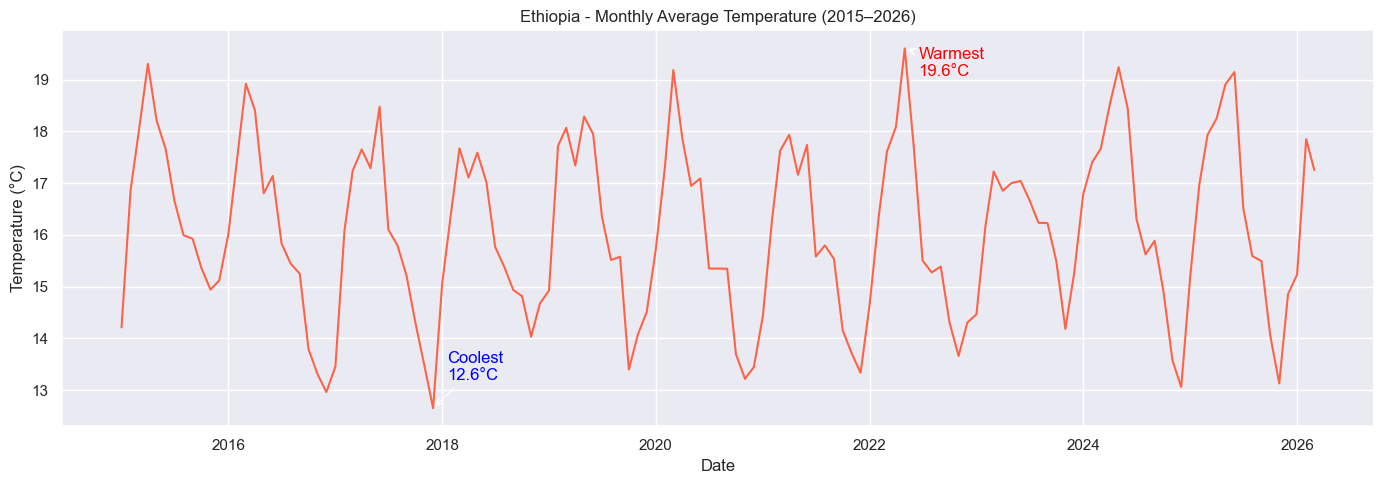

In [23]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato")

# Annotate warmest and coolest
warmest = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
coolest = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.annotate(f'Warmest\n{warmest["T2M"]:.1f}°C', 
             xy=(warmest["Date"], warmest["T2M"]),
             xytext=(10, -20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="red")

plt.annotate(f'Coolest\n{coolest["T2M"]:.1f}°C', 
             xy=(coolest["Date"], coolest["T2M"]),
             xytext=(10, 20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="blue")

plt.title("Ethiopia - Monthly Average Temperature (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.savefig("notebooks/ethiopia_temp_trend.png")
plt.show()

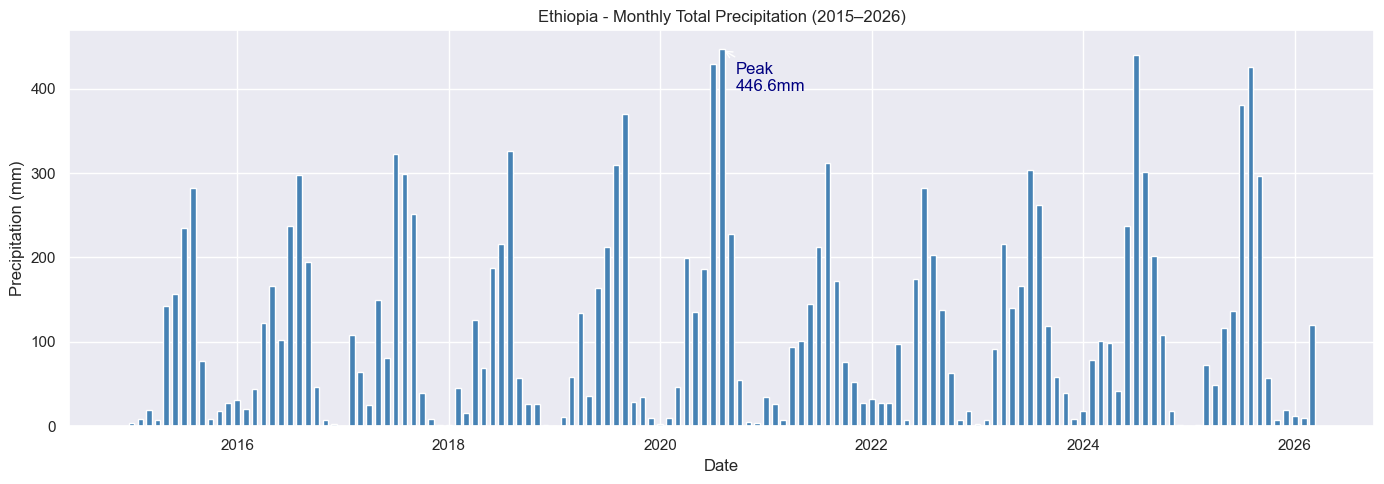

In [24]:
monthly_precip = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_precip["Date"] = pd.to_datetime(monthly_precip[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_precip["Date"], monthly_precip["PRECTOTCORR"], color="steelblue", width=20)

peak = monthly_precip.loc[monthly_precip["PRECTOTCORR"].idxmax()]
plt.annotate(f'Peak\n{peak["PRECTOTCORR"]:.1f}mm',
             xy=(peak["Date"], peak["PRECTOTCORR"]),
             xytext=(10, -30), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="navy")

plt.title("Ethiopia - Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.tight_layout()
plt.savefig("notebooks/ethiopia_precip.png")
plt.show()

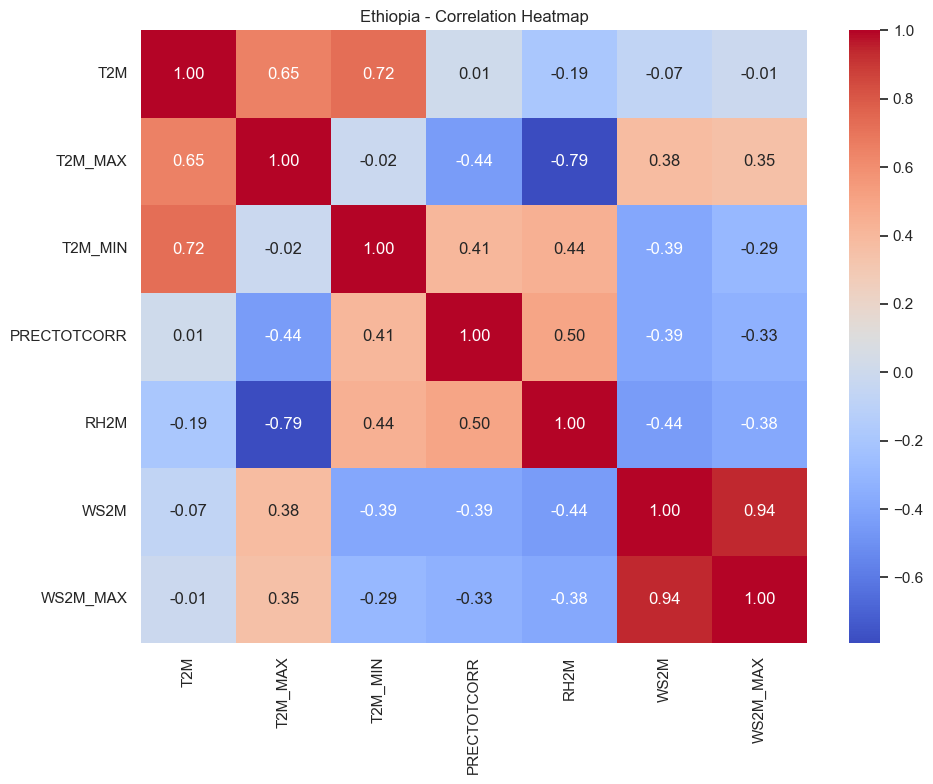

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ethiopia - Correlation Heatmap")
plt.tight_layout()
plt.savefig("notebooks/ethiopia_corr.png")
plt.show()

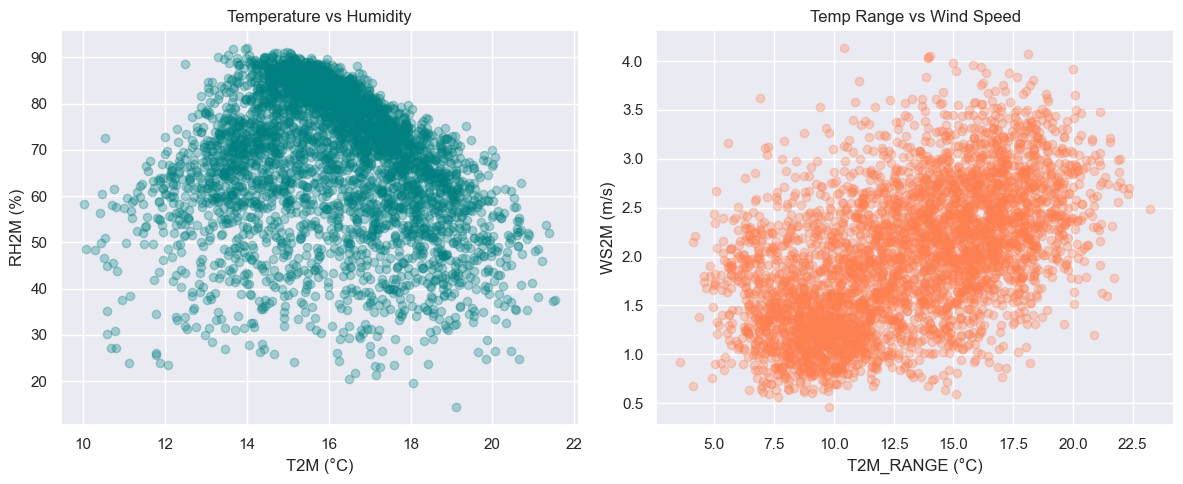

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="teal")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].set_title("Temperature vs Humidity")

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="coral")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].set_title("Temp Range vs Wind Speed")

plt.tight_layout()
plt.savefig("notebooks/ethiopia_scatter.png")
plt.show()

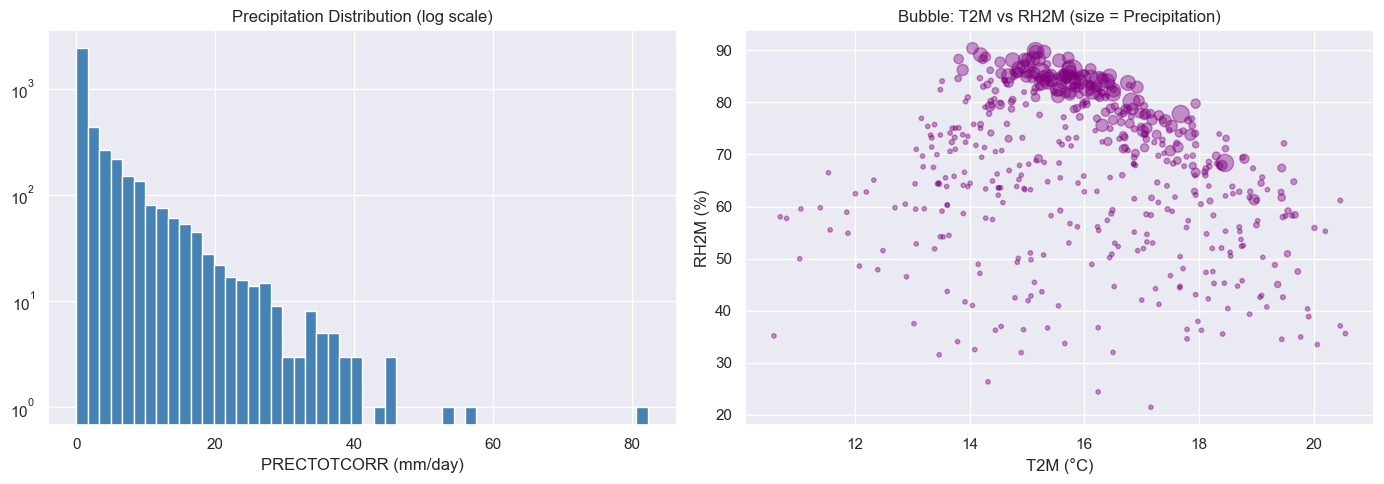

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log scale
axes[0].hist(df["PRECTOTCORR"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Precipitation Distribution (log scale)")
axes[0].set_xlabel("PRECTOTCORR (mm/day)")

# Bubble chart
sample = df.sample(500, random_state=42)
axes[1].scatter(sample["T2M"], sample["RH2M"],
                s=sample["PRECTOTCORR"].fillna(0) * 5 + 10,
                alpha=0.4, color="purple")
axes[1].set_xlabel("T2M (°C)")
axes[1].set_ylabel("RH2M (%)")
axes[1].set_title("Bubble: T2M vs RH2M (size = Precipitation)")

plt.tight_layout()
plt.savefig("notebooks/ethiopia_dist.png")
plt.show()